# Customer Churn Prediction with Explainable AI

## Objective
Predict whether a telecom customer is likely to churn and explain
the major factors responsible for the prediction using SHAP.

## Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- SHAP

## Machine Learning
- Logistic Regression
- Decision Tree
- Random Forest

## Evaluation Metrics
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix


In [1]:
# Install SHAP
!pip install shap -q

In [2]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

import shap

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [12]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


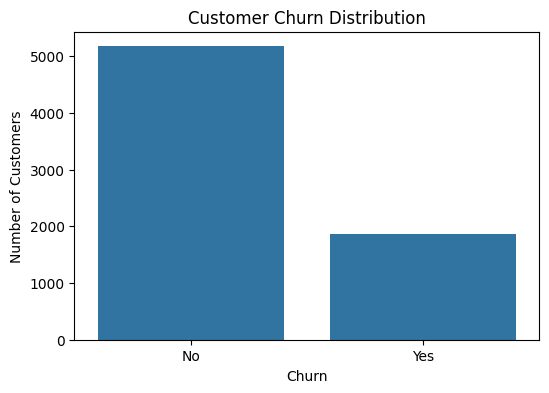

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
# Check dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [15]:
# Check all column names

for i, col in enumerate(df.columns, 1):
    print(i, ":", col)

1 : customerID
2 : gender
3 : SeniorCitizen
4 : Partner
5 : Dependents
6 : tenure
7 : PhoneService
8 : MultipleLines
9 : InternetService
10 : OnlineSecurity
11 : OnlineBackup
12 : DeviceProtection
13 : TechSupport
14 : StreamingTV
15 : StreamingMovies
16 : Contract
17 : PaperlessBilling
18 : PaymentMethod
19 : MonthlyCharges
20 : TotalCharges
21 : Churn


In [16]:
# Check data types

df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [17]:
# Check missing values

print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [18]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [19]:
for col in df.columns:
    print("\n", col)
    print(df[col].unique()[:10])


 customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU']

 gender
['Female' 'Male']

 SeniorCitizen
[0 1]

 Partner
['Yes' 'No']

 Dependents
['No' 'Yes']

 tenure
[ 1 34  2 45  8 22 10 28 62 13]

 PhoneService
['No' 'Yes']

 MultipleLines
['No phone service' 'No' 'Yes']

 InternetService
['DSL' 'Fiber optic' 'No']

 OnlineSecurity
['No' 'Yes' 'No internet service']

 OnlineBackup
['Yes' 'No' 'No internet service']

 DeviceProtection
['No' 'Yes' 'No internet service']

 TechSupport
['No' 'Yes' 'No internet service']

 StreamingTV
['No' 'Yes' 'No internet service']

 StreamingMovies
['No' 'Yes' 'No internet service']

 Contract
['Month-to-month' 'One year' 'Two year']

 PaperlessBilling
['Yes' 'No']

 PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

 MonthlyCharges
[ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15]

 Total

In [20]:
print(df["TotalCharges"].dtype)

object


In [21]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [22]:
print(df["TotalCharges"].isnull().sum())

11


In [23]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [24]:
df = df.dropna(subset=["TotalCharges"])

In [25]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7032, 21)


In [26]:
print(df.isnull().sum().sum())

0


In [27]:
df = df.drop("customerID", axis=1)

In [28]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [30]:
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [31]:
df.select_dtypes(include=np.number).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')

In [32]:
df.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [33]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


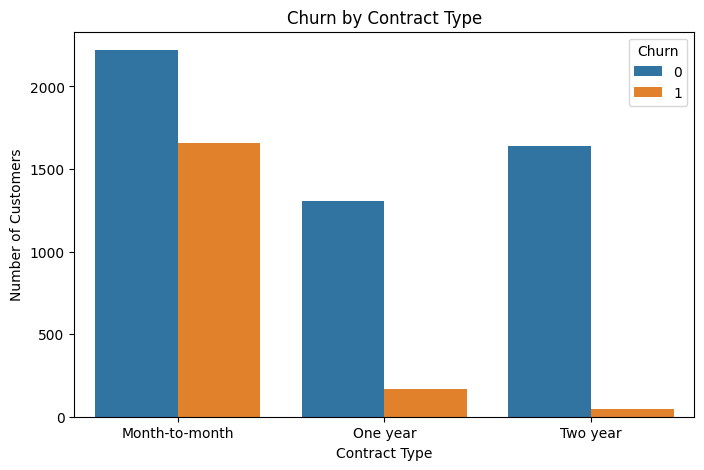

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

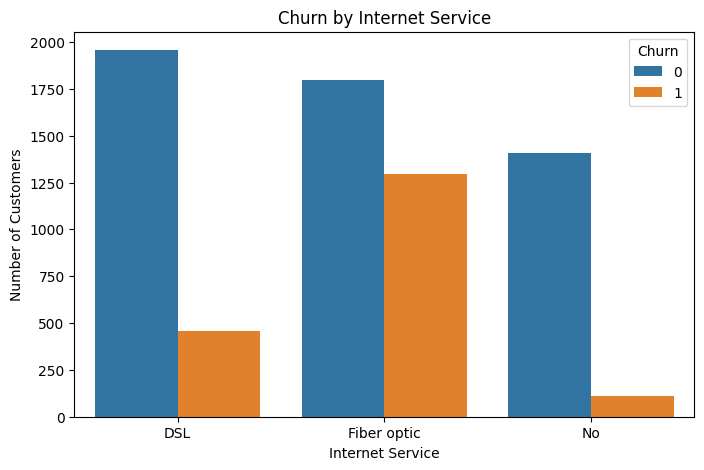

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

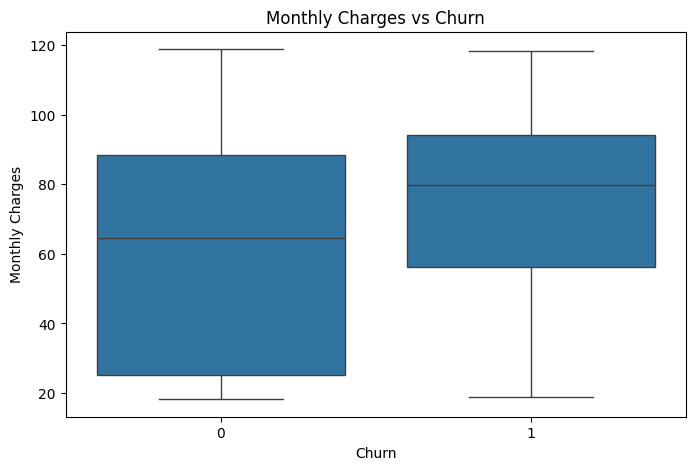

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

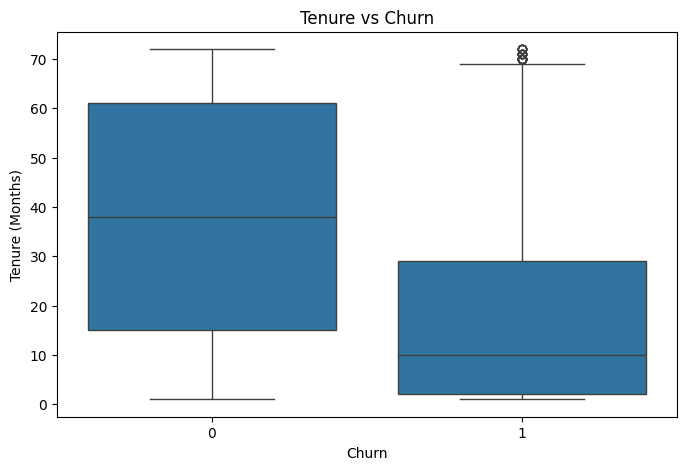

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

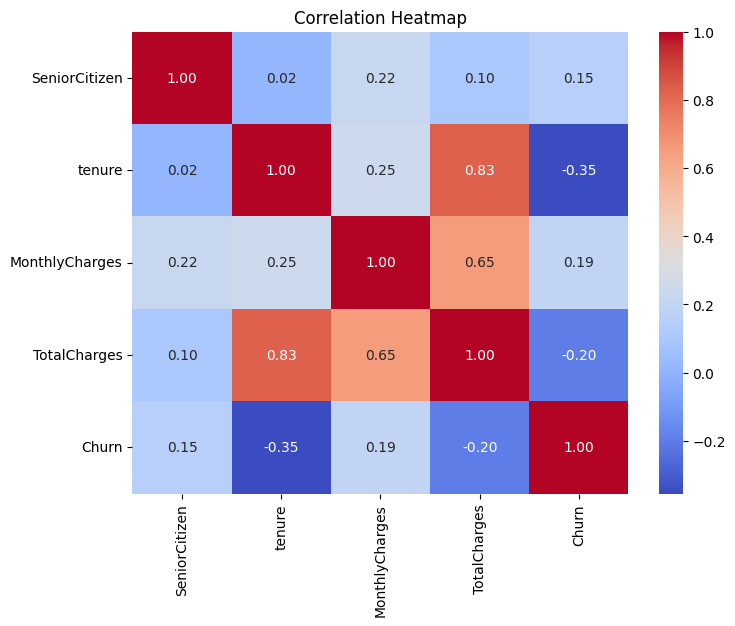

In [38]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [39]:
# Separate features and target

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [40]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target:
Churn


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 19)
Testing data: (1407, 19)


In [42]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created!")

Logistic Regression pipeline created!


In [45]:

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [46]:
y_pred = logistic_pipeline.predict(X_test)

In [47]:
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [48]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Performance")
print("----------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Model Performance
----------------------------
Accuracy : 0.7257
Precision: 0.4901
Recall   : 0.7968
F1 Score : 0.6069
ROC-AUC  : 0.8351


In [49]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



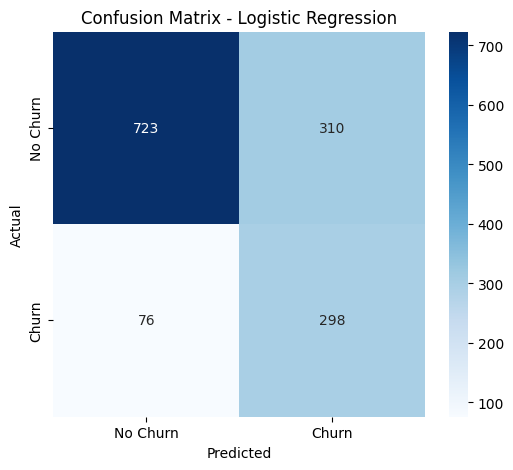

In [50]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [51]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=6,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Decision Tree pipeline created!")

Decision Tree pipeline created!


In [52]:
decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [53]:
dt_pred = decision_tree_pipeline.predict(X_test)

dt_prob = decision_tree_pipeline.predict_proba(X_test)[:, 1]

In [54]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_prob)

print("Decision Tree Performance")
print("----------------------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))
print("ROC-AUC  :", round(dt_roc_auc, 4))

Decision Tree Performance
----------------------------
Accuracy : 0.7335
Precision: 0.4992
Recall   : 0.7995
F1 Score : 0.6146
ROC-AUC  : 0.8182


In [55]:
print(classification_report(
    y_test,
    dt_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1033
       Churn       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.73      0.75      1407



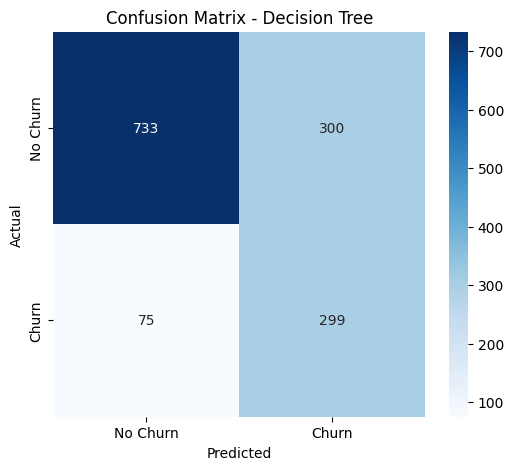

In [56]:
cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [57]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created!")

Random Forest pipeline created!


In [58]:
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [59]:
rf_pred = random_forest_pipeline.predict(X_test)

rf_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [60]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Performance")
print("----------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Performance
----------------------------
Accuracy : 0.7633
Precision: 0.5414
Recall   : 0.7166
F1 Score : 0.6168
ROC-AUC  : 0.8315


In [61]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.83      1033
       Churn       0.54      0.72      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.76      0.77      1407



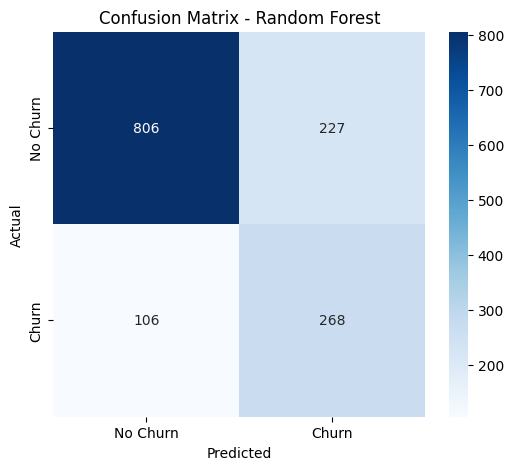

In [62]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [63]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7257,0.4901,0.7968,0.6069,0.8351
1,Decision Tree,0.7335,0.4992,0.7995,0.6146,0.8182
2,Random Forest,0.7633,0.5414,0.7166,0.6168,0.8315


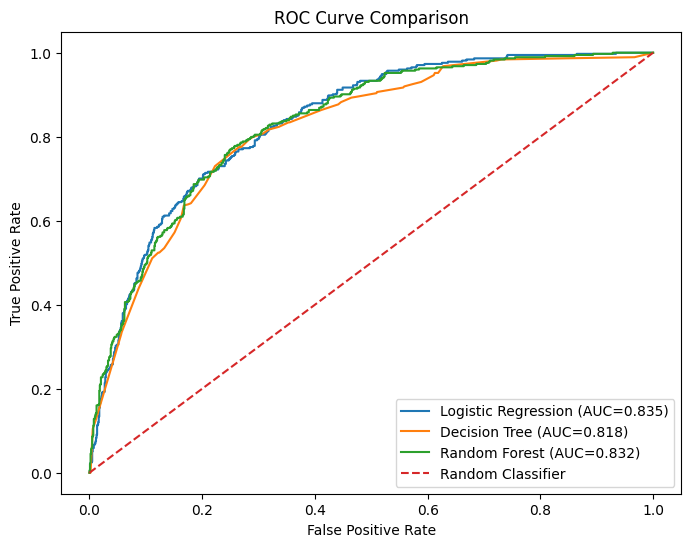

In [64]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={roc_auc:.3f})"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC={dt_roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [65]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7257,0.4901,0.7968,0.6069,0.8351
1,Decision Tree,0.7335,0.4992,0.7995,0.6146,0.8182
2,Random Forest,0.7633,0.5414,0.7166,0.6168,0.8315


In [66]:
# Extract the preprocessing part

preprocessor_fitted = random_forest_pipeline.named_steps["preprocessor"]

# Transform test data
X_test_transformed = preprocessor_fitted.transform(X_test)

print("Transformed test data shape:", X_test_transformed.shape)

Transformed test data shape: (1407, 45)


In [67]:
feature_names = preprocessor_fitted.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 45


In [68]:
print(feature_names[:20])

['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service']


In [69]:
rf_model = random_forest_pipeline.named_steps["classifier"]

print(rf_model)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       n_jobs=-1, random_state=42)


In [70]:
explainer = shap.TreeExplainer(rf_model)

In [71]:
shap_values = explainer.shap_values(X_test_transformed)

print(type(shap_values))

<class 'numpy.ndarray'>


In [72]:
print(np.array(shap_values).shape)

(1407, 45, 2)


In [73]:
shap_values_churn = shap_values[:, :, 1]

In [74]:
shap_values_churn = shap_values

In [75]:
shap_values_churn = shap_values

In [76]:
shap_values_churn

array([[[ 3.88573446e-03, -3.88573446e-03],
        [ 6.89110174e-02, -6.89110174e-02],
        [ 2.21523899e-02, -2.21523899e-02],
        ...,
        [ 8.95311506e-03, -8.95311506e-03],
        [ 1.82358452e-02, -1.82358452e-02],
        [ 1.28318110e-03, -1.28318110e-03]],

       [[ 1.01358324e-03, -1.01358324e-03],
        [-6.45101032e-02,  6.45101032e-02],
        [-5.79689722e-04,  5.79689722e-04],
        ...,
        [-1.56691635e-04,  1.56691635e-04],
        [ 2.90568683e-02, -2.90568683e-02],
        [-1.80694671e-03,  1.80694671e-03]],

       [[ 2.10587741e-03, -2.10587741e-03],
        [ 5.12292297e-02, -5.12292297e-02],
        [ 2.39319131e-02, -2.39319131e-02],
        ...,
        [-8.38701536e-05,  8.38701536e-05],
        [ 1.43838168e-02, -1.43838168e-02],
        [ 6.73050743e-03, -6.73050743e-03]],

       ...,

       [[ 2.17114930e-03, -2.17114930e-03],
        [-4.17201409e-02,  4.17201409e-02],
        [ 2.56524864e-02, -2.56524864e-02],
        ...,
     

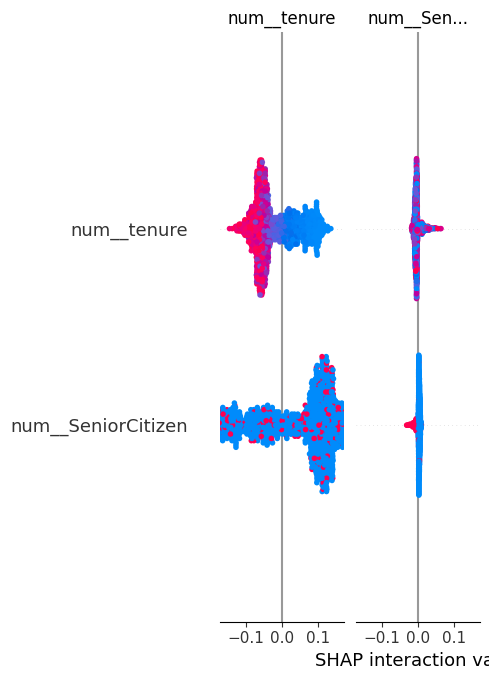

In [77]:
shap.summary_plot(
    shap_values_churn,
    X_test_transformed,
    feature_names=feature_names,
    show=True
)

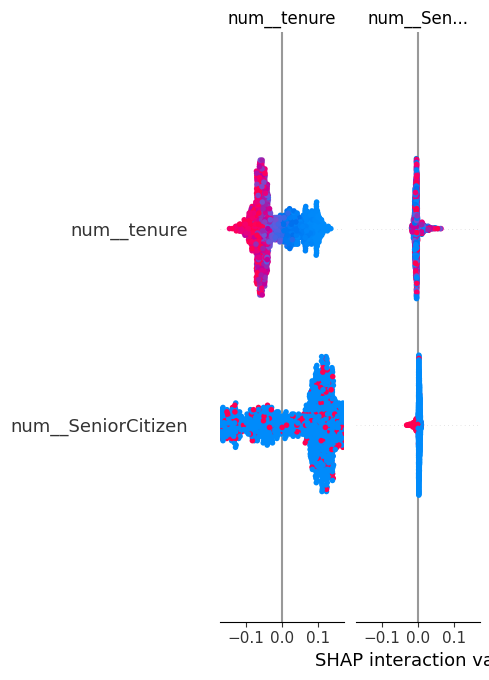

In [78]:
shap.summary_plot(
    shap_values_churn,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [79]:
customer_index = 0

In [80]:
X_test.iloc[customer_index]

,974
gender,Female
SeniorCitizen,0
Partner,Yes
Dependents,Yes
tenure,59
PhoneService,Yes
MultipleLines,No
InternetService,DSL
OnlineSecurity,No
OnlineBackup,Yes


In [81]:
print("Actual Churn:", y_test.iloc[customer_index])

Actual Churn: 0


In [82]:
print("Predicted Churn:", rf_pred[customer_index])

Predicted Churn: 0


In [83]:
print(
    "Churn Probability:",
    round(rf_prob[customer_index] * 100, 2),
    "%"
)

Churn Probability: 1.8 %


In [85]:
print("SHAP values shape:", np.array(shap_values).shape)
print("SHAP churn shape:", np.array(shap_values_churn).shape)
print("Expected value:", explainer.expected_value)

SHAP values shape: (1407, 45, 2)
SHAP churn shape: (1407, 45, 2)
Expected value: [0.50029687 0.49970313]


In [86]:
# Select one customer
customer_index = 0

# Get SHAP values for this customer
customer_shap = shap_values_churn[customer_index]

print("Customer SHAP shape:", np.array(customer_shap).shape)

Customer SHAP shape: (45, 2)


In [87]:
if np.ndim(explainer.expected_value) > 0:
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

print("Base value:", base_value)

Base value: 0.49970312863465033


In [89]:
customer_shap = shap_values[customer_index, :, 1]

print("Customer SHAP shape:", customer_shap.shape)

Customer SHAP shape: (45,)


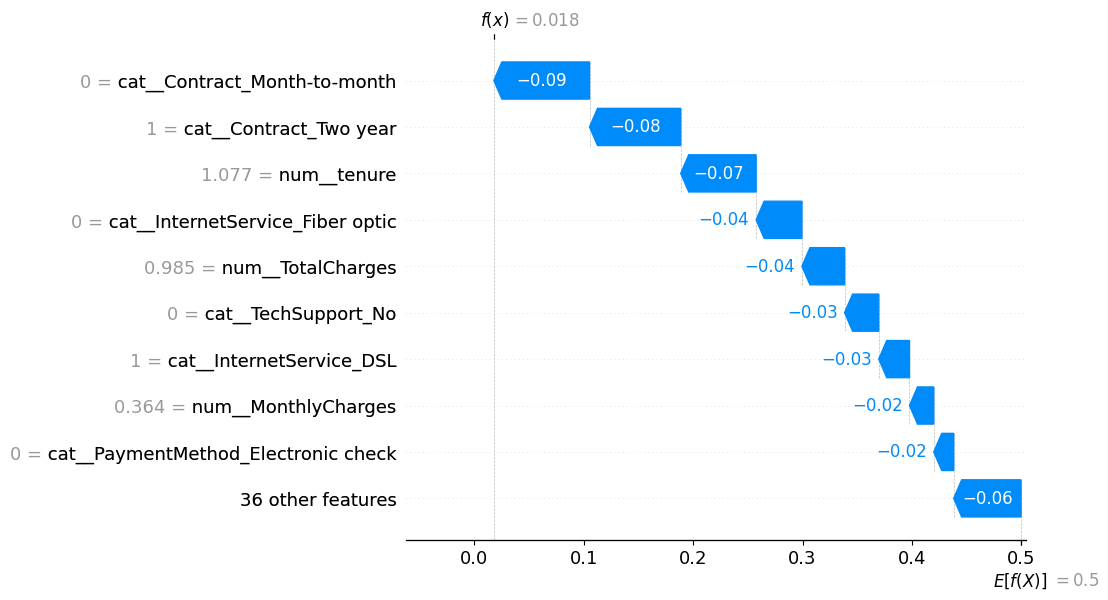

In [90]:
shap.waterfall_plot(
    shap.Explanation(
        values=customer_shap,
        base_values=explainer.expected_value[1],
        data=X_test_transformed[customer_index],
        feature_names=feature_names
    )
)

In [91]:
import os

os.makedirs("outputs", exist_ok=True)

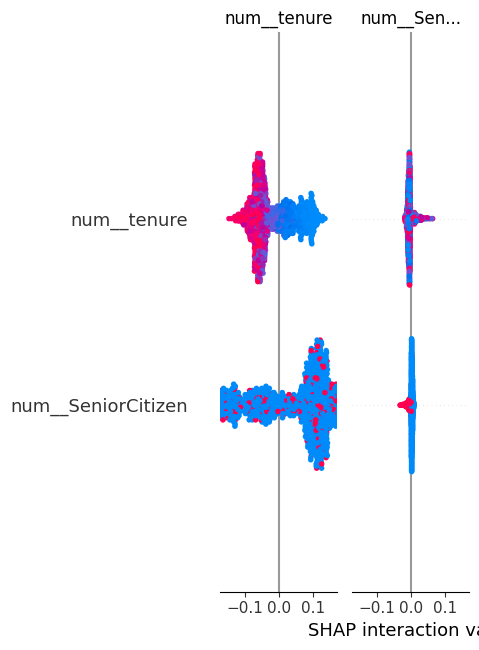

In [92]:
shap.summary_plot(
    shap_values_churn,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(
    "outputs/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [93]:
final_results = results.copy()

final_results = final_results.round(4)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7257,0.4901,0.7968,0.6069,0.8351
1,Decision Tree,0.7335,0.4992,0.7995,0.6146,0.8182
2,Random Forest,0.7633,0.5414,0.7166,0.6168,0.8315


In [94]:
final_results.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved!")

Model comparison saved!


In [95]:
final_results.sort_values(
    by=["Recall", "F1 Score", "ROC-AUC"],
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,0.7335,0.4992,0.7995,0.6146,0.8182
0,Logistic Regression,0.7257,0.4901,0.7968,0.6069,0.8351
2,Random Forest,0.7633,0.5414,0.7166,0.6168,0.8315


In [96]:
final_model = random_forest_pipeline

final_pred = rf_pred
final_prob = rf_prob

print("Final model: Random Forest")

Final model: Random Forest


In [97]:
final_model = logistic_pipeline

final_pred = y_pred
final_prob = y_prob

print("Final model: Logistic Regression")

Final model: Logistic Regression


In [98]:
final_model = decision_tree_pipeline

final_pred = dt_pred
final_prob = dt_prob

print("Final model: Decision Tree")

Final model: Decision Tree


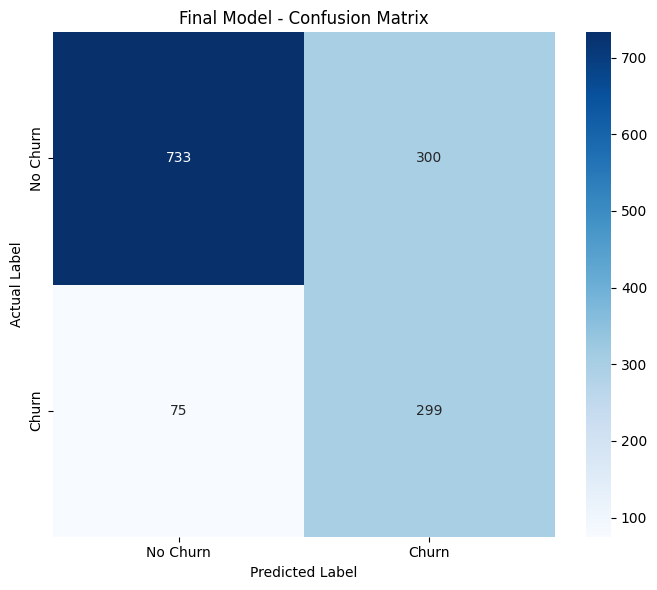

In [99]:
cm_final = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Final Model - Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "outputs/final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
print(
    classification_report(
        y_test,
        final_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1033
       Churn       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.73      0.75      1407



In [101]:
print("FINAL MODEL PERFORMANCE")
print("=======================")

print("Accuracy :", round(
    accuracy_score(y_test, final_pred), 4
))

print("Precision:", round(
    precision_score(y_test, final_pred), 4
))

print("Recall   :", round(
    recall_score(y_test, final_pred), 4
))

print("F1 Score :", round(
    f1_score(y_test, final_pred), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, final_prob), 4
))

FINAL MODEL PERFORMANCE
Accuracy : 0.7335
Precision: 0.4992
Recall   : 0.7995
F1 Score : 0.6146
ROC-AUC  : 0.8182


In [102]:
import joblib

In [103]:
joblib.dump(
    final_model,
    "outputs/customer_churn_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [104]:
import os

print(os.path.getsize(
    "outputs/customer_churn_model.pkl"
), "bytes")

17435 bytes


In [105]:
def predict_customer_churn(customer_data):

    customer_df = pd.DataFrame(
        [customer_data]
    )

    prediction = final_model.predict(
        customer_df
    )[0]

    probability = final_model.predict_proba(
        customer_df
    )[0][1]

    if prediction == 1:
        result = "Likely to Churn"
    else:
        result = "Likely to Stay"

    return {
        "prediction": result,
        "churn_probability": round(
            probability * 100,
            2
        )
    }

In [106]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [107]:
sample_customer = X.iloc[0].to_dict()

In [108]:
prediction_result = predict_customer_churn(
    sample_customer
)

print(prediction_result)

{'prediction': 'Likely to Churn', 'churn_probability': np.float64(76.3)}


In [109]:
for i in range(5):

    customer = X_test.iloc[i].to_dict()

    result = predict_customer_churn(customer)

    print(
        f"Customer {i+1}:",
        result
    )

Customer 1: {'prediction': 'Likely to Stay', 'churn_probability': np.float64(3.78)}
Customer 2: {'prediction': 'Likely to Churn', 'churn_probability': np.float64(87.43)}
Customer 3: {'prediction': 'Likely to Stay', 'churn_probability': np.float64(3.78)}
Customer 4: {'prediction': 'Likely to Stay', 'churn_probability': np.float64(28.06)}
Customer 5: {'prediction': 'Likely to Stay', 'churn_probability': np.float64(21.74)}


In [110]:
metrics_text = f"""
CUSTOMER CHURN PREDICTION PROJECT
=================================

Final Model: {type(final_model.named_steps["classifier"]).__name__}

Accuracy : {accuracy_score(y_test, final_pred):.4f}
Precision: {precision_score(y_test, final_pred):.4f}
Recall   : {recall_score(y_test, final_pred):.4f}
F1 Score : {f1_score(y_test, final_pred):.4f}
ROC-AUC  : {roc_auc_score(y_test, final_prob):.4f}

Dataset:
Telco Customer Churn

Explainability:
SHAP
"""

with open(
    "outputs/final_metrics.txt",
    "w"
) as f:
    f.write(metrics_text)

print("Final metrics saved!")

Final metrics saved!


In [111]:
import os

for root, dirs, files in os.walk("outputs"):
    for file in files:
        print(os.path.join(root, file))

outputs/shap_feature_importance.png
outputs/customer_churn_model.pkl
outputs/final_confusion_matrix.png
outputs/model_comparison.csv
outputs/final_metrics.txt
